In [13]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from nltk.stem import SnowballStemmer
from spellchecker import SpellChecker

from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

# Домашнє завдання: Побудова класифікатора сентименту на основі набору даних Tweet Sentiment Extraction

**Мета:** Провести аналіз набору даних, виконати векторизацію текстових даних за допомогою методів bag-of-words та TF-IDF, порівняти їх, побудувати класифікатор та провести аналіз помилок.

**Набір даних:**
Дані беремо з цього змагання на Kaggle: https://www.kaggle.com/competitions/tweet-sentiment-extraction/data?select=train.csv


Якщо не вдається завантажиит з Kaggle, ось тут можна - https://drive.google.com/file/d/1kfu5zCRsDHxoBZigBlGIcCieKlws02HT/view?usp=sharing

Оригінальне змагання має дещо іншу задачу, але ми будемо поки будувати саме класифікатор.

Увага! В цьому наборі завдань для простоти експериментів ми будемо спочатку робити векторизацію на всьому наборі даних, а потім розбивку на train i test. В робочих проєктах ми теж можемо використати цей підхід для швидшої побудови PoC (proof of concept). Але фінальне рішення, яке ми будемо деплоїти - треба проводити за правилом - спочатку розбивка на трейн і тест, потім пишемо обробку для трейну, навчаємо векторизатори. І потім використовуємо готові векторизатори для тесту і всіх даних на етапі передбачення (інференсу).

### Завдання 1. Завантаження та ознайомлення з набором даних

- Завантажте набір даних `train.csv` з посилання та ознайомтеся з його структурою.
- Виведіть перші 5 рядків та основну статистику: кількість записів, типи колонок, кількість пропущених значень.
- Видаліть записи, в яких є пропущені значення.



In [2]:
df = pd.read_csv("../assets/hw_4_1/tweet_sentiment_train.csv.zip")
display(df.head())
df.info()
print(df.isnull().sum())
df_cleaned = df.dropna()
print(df.shape)
print(df_cleaned.shape)

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27481 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27481 non-null  object
dtypes: object(4)
memory usage: 858.9+ KB
textID           0
text             1
selected_text    1
sentiment        0
dtype: int64
(27481, 4)
(27480, 4)


### Завдання 2. Exploratory Data Analysis

- Проведіть аналіз кількості класів та розподілу міток. Класи знаходяться в колонці `sentiment`.
- Візуалізуйте розподіл довжин текстів в символах та зробіть висновок про довжини постів: якої довжини постів найбільше, що бачите з розподілу?



Class counts:
 sentiment
neutral     11118
positive     8582
negative     7781
Name: count, dtype: int64

Class proportions:
 sentiment
neutral     0.4046
positive    0.3123
negative    0.2831
Name: count, dtype: float64


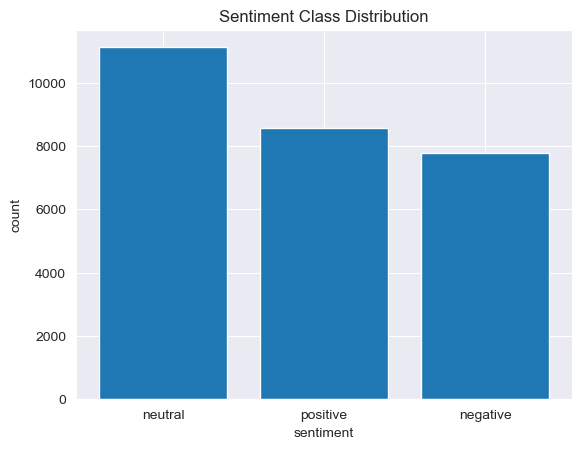

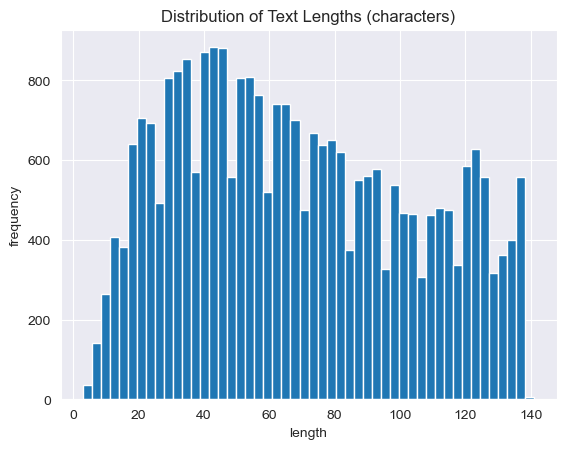


Text length summary:
 count    27481.000000
mean        68.327645
std         35.605403
min          3.000000
25%         39.000000
50%         64.000000
75%         97.000000
max        141.000000
Name: text_length, dtype: float64


In [3]:
sentiment_counts = df["sentiment"].value_counts()
print("Class counts:\n", sentiment_counts)
print("\nClass proportions:\n", (sentiment_counts / len(df)).round(4))

plt.figure()
plt.bar(sentiment_counts.index.astype(str), sentiment_counts.values)
plt.title("Sentiment Class Distribution")
plt.xlabel("sentiment")
plt.ylabel("count")
plt.show()

df["text"] = df["text"].astype(str)
df["text_length"] = df["text"].str.len()

plt.figure()
plt.hist(df["text_length"], bins=50)
plt.title("Distribution of Text Lengths (characters)")
plt.xlabel("length")
plt.ylabel("frequency")
plt.show()

print("\nText length summary:\n", df["text_length"].describe())

### Task 2 — Summary

The dataset contains **27,481** samples divided into three sentiment classes:

- **Neutral:** 11,118 (40.46%)
- **Positive:** 8,582 (31.23%)
- **Negative:** 7,781 (28.31%)

The distribution is relatively balanced, with a slight dominance of neutral texts.

Regarding text length:
- Mean length: **68.3 characters**
- Median: **64 characters**
- The majority of texts fall within **30–50 characters**, indicating that most posts are short and concise.
- The distribution is right-skewed, with fewer longer posts extending up to **140 characters**.

Overall, the dataset primarily consists of short social media messages with a moderate balance across sentiment categories.


### Завдання 3. Попередня обробка текстових даних та векторизація з bag of words


Наша задача тут отримати вектори методом bag of words колонки `text`, виконавши попередню обробку тексту.
Попередня обробка має включати
- видалення stopwords необхідної мови
- токенізація (розбиття текстів на фрагменти по 1 слову)
- стеммінг слів зі `SnowballStemmer`.
- самостійно задайте кількість слів в словнику для `sklearn.feature_extraction.text.CountVectorizer`. Можливо для цього доведеться виконати додатковий аналіз.

Ви також можете додати сюди додаткові методи очистки текстів, наприклад, видалення деяких символів чи груп символів, якщо в процесі роботи побачите, що хочете щось видалити.

Напишіть код аби виконати це завдання. Перед цим рекомендую детально ознайомитись з тим, що робить обʼєкт `sklearn.feature_extraction.text.CountVectorizer` за замовченням.

Це завдання можна виконати двома способами - один - максимально подібно до того, як ми це робили в лекції, другий - дещо інакше перегрупувавши етапи обробки тексту.




In [4]:
df["text"] = df["text"].astype(str)

stemmer = SnowballStemmer("english")
stops = set(ENGLISH_STOP_WORDS)

def analyzer(text):
    tokens = re.findall(r"[A-Za-z']+", text.lower())
    tokens = [t for t in tokens if t not in stops and len(t) > 1]
    tokens = [stemmer.stem(t) for t in tokens]
    return tokens

vectorizer_full = CountVectorizer(analyzer=analyzer, min_df=2)
X_full = vectorizer_full.fit_transform(df["text"])

vocab = np.array(vectorizer_full.get_feature_names_out())
freq = np.asarray(X_full.sum(axis=0)).ravel()
order = np.argsort(freq)[::-1]
vocab_sorted = vocab[order]
freq_sorted = freq[order]

print("Full vocabulary size:", len(vocab_sorted))
print("Top 20 words:")
for w, f in zip(vocab_sorted[:20], freq_sorted[:20]):
    print(f"{w:<15} {f}")

Full vocabulary size: 7952
Top 20 words:
day             2497
just            2278
good            1600
work            1530
love            1486
like            1462
http            1247
today           1155
go              1105
time            1104
got             1099
lol             1029
happi           1014
thank           991
want            991
know            980
miss            968
realli          916
com             900
im              887


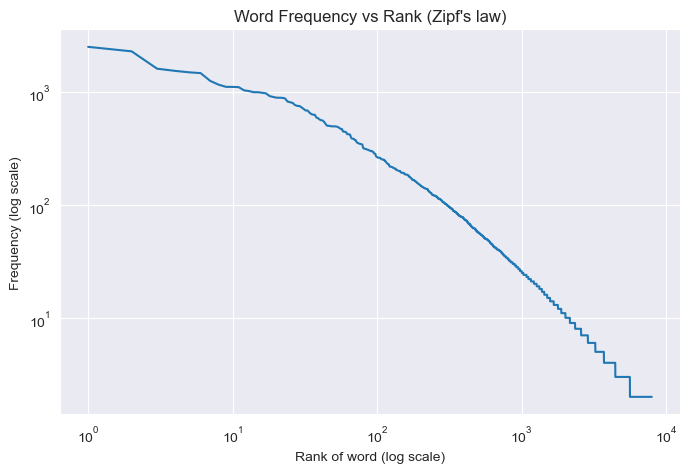

In [5]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(freq_sorted)+1), freq_sorted)
plt.xscale("log")
plt.yscale("log")
plt.title("Word Frequency vs Rank (Zipf's law)")
plt.xlabel("Rank of word (log scale)")
plt.ylabel("Frequency (log scale)")
plt.grid(True)
plt.show()

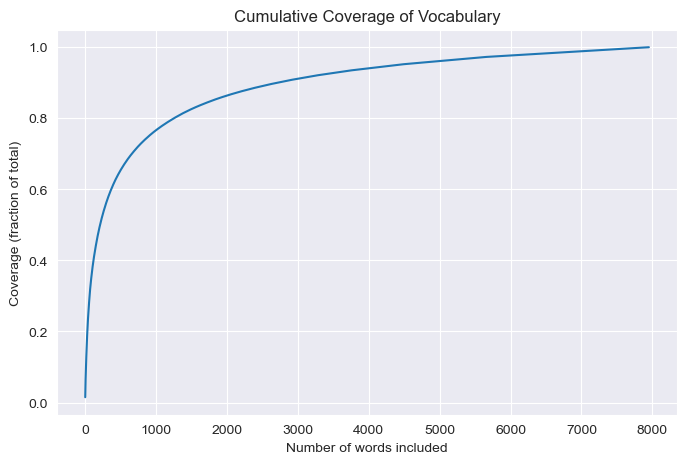

  500 words cover 65.41% of text
 1000 words cover 76.65% of text
 2000 words cover 86.41% of text
 3000 words cover 91.14% of text
 5000 words cover 96.12% of text


In [6]:
coverage = np.cumsum(freq_sorted) / freq_sorted.sum()

plt.figure(figsize=(8,5))
plt.plot(range(1, len(coverage)+1), coverage)
plt.title("Cumulative Coverage of Vocabulary")
plt.xlabel("Number of words included")
plt.ylabel("Coverage (fraction of total)")
plt.grid(True)
plt.show()

for thresh in [500, 1000, 2000, 3000, 5000]:
    print(f"{thresh:5d} words cover {coverage[min(thresh, len(coverage))-1]*100:.2f}% of text")

In [7]:
cutoff = 4000

print(f"\nTop {cutoff} most frequent words will be kept.")
print(f"Words beyond rank {cutoff} will be removed ({len(vocab_sorted) - cutoff} total).")

kept_words = list(zip(vocab_sorted[:cutoff], freq_sorted[:cutoff]))
dropped_words = list(zip(vocab_sorted[cutoff:], freq_sorted[cutoff:]))

print("\n--- Sample of KEPT words (top 20) ---")
for w, f in kept_words[:20]:
    print(f"{w:<15} {f}")

print("\n--- Sample of DROPPED words (20 random from tail) ---")
for w, f in random.sample(dropped_words, 20):
    print(f"{w:<15} {f}")

spell = SpellChecker(language="en")
tail_tokens = [w for w, _ in dropped_words[:500]]
misspelled = spell.unknown(tail_tokens)
print(f"\nIn the first 500 dropped words, {len(misspelled)} look like misspellings ({len(misspelled)/len(tail_tokens)*100:.1f}%).")

print("Sample likely misspelled words:")
for w in list(misspelled)[:20]:
    print(w)


Top 4000 most frequent words will be kept.
Words beyond rank 4000 will be removed (3952 total).

--- Sample of KEPT words (top 20) ---
day             2497
just            2278
good            1600
work            1530
love            1486
like            1462
http            1247
today           1155
go              1105
time            1104
got             1099
lol             1029
happi           1014
thank           991
want            991
know            980
miss            968
realli          916
com             900
im              887

--- Sample of DROPPED words (20 random from tail) ---
dixon           2
deffo           2
newbi           3
throwback       4
ina             2
arnold          4
distant         3
oooo            4
zulu            3
daze            3
twilightguy     2
jessi           3
guin            2
fallin          2
evict           2
ge              2
when            2
ribena          2
bitten          3
remark          2

In the first 500 dropped words, 221

In [8]:
spell = SpellChecker(language="en")

cut_idx = int(np.searchsorted(coverage, 0.90))
head_terms = vocab_sorted[:cut_idx+1]
tail_terms = vocab_sorted[cut_idx+1:]
misspelled = spell.unknown(tail_terms)
tail_kept = [w for w in tail_terms if w not in misspelled]
final_terms = np.concatenate([head_terms, np.array(tail_kept)])
vocabulary = {t: i for i, t in enumerate(final_terms)}

print("Head size:", len(head_terms))
print("Tail size:", len(tail_terms))
print("Tail misspelled removed:", len(misspelled))
print("Final vocabulary size:", len(final_terms))

vectorizer = CountVectorizer(analyzer=analyzer, min_df=2, vocabulary=vocabulary)
X = vectorizer.fit_transform(df["text"])
print("Matrix shape:", X.shape)

Head size: 2709
Tail size: 5243
Tail misspelled removed: 2614
Final vocabulary size: 5338
Matrix shape: (27481, 5338)


In [9]:
kept_set = set(final_terms)
kept_mask = np.isin(vocab_sorted, list(kept_set))
total_tokens = int(freq_sorted.sum())
kept_tokens = int(freq_sorted[kept_mask].sum())
print(f"Coverage by final vocabulary: {kept_tokens/total_tokens*100:.2f}% ({kept_tokens}/{total_tokens} tokens)")

Coverage by final vocabulary: 95.28% (160044/167981 tokens)


### Завдання 4. Побудова класифікатора

- Розділіть індекси даних на навчальний та тестовий набори в обраному співвівдношенні. Використовуючи отримані індекси сфомуйте набори для тренування класифікатора `X_train_bow, X_test_bow, y_train, y_test`.
- Навчіть класифікатор (наприклад, Logistic Regression, Decision Tree або один з алгоритмів бустингу) на даних, векторизованих методом bag-of-words. Спробуйте кілька моделей і оберіть найбільш точну :)
- Виведіть інформацію, яка дає можливість оцінити якість класифікації.
- Оцініть якість фінальної класифікації: вона хороша чи не дуже?



In [10]:
y_labels = df["sentiment"]

X_train_bow, X_test_bow, y_train, y_test = train_test_split(
    X, y_labels, test_size=0.2, random_state=42, stratify=y_labels
)

models = {
    "LogReg": LogisticRegression(max_iter=300),
    "DecisionTree": DecisionTreeClassifier(max_depth=30, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_bow, y_train)
    preds = model.predict(X_test_bow)
    f1 = f1_score(y_test, preds, average="macro")
    acc = accuracy_score(y_test, preds)
    results[name] = (acc, f1)
    print(f"\n{name}")
    print(classification_report(y_test, preds, digits=3))
    print("Confusion matrix:\n", confusion_matrix(y_test, preds))

print("\nSummary (Accuracy, Macro-F1):")
for k, (acc, f1) in results.items():
    print(f"{k:<18} acc={acc:.4f}, f1={f1:.4f}")


LogReg
              precision    recall  f1-score   support

    negative      0.723     0.621     0.668      1556
     neutral      0.634     0.738     0.682      2224
    positive      0.771     0.706     0.737      1717

    accuracy                          0.695      5497
   macro avg      0.710     0.688     0.696      5497
weighted avg      0.702     0.695     0.695      5497

Confusion matrix:
 [[ 966  504   86]
 [ 309 1642  273]
 [  61  444 1212]]

DecisionTree
              precision    recall  f1-score   support

    negative      0.789     0.374     0.507      1556
     neutral      0.563     0.859     0.680      2224
    positive      0.780     0.620     0.691      1717

    accuracy                          0.647      5497
   macro avg      0.711     0.618     0.626      5497
weighted avg      0.695     0.647     0.635      5497

Confusion matrix:
 [[ 582  880   94]
 [ 108 1910  206]
 [  48  604 1065]]

GradientBoosting
              precision    recall  f1-score   supp

### Summary

| Model | Accuracy | Macro-F1 | Evaluation |
|--------|-----------|-----------|-------------|
| **Logistic Regression** | **0.695** | **0.696** | Achieved the best balance between classes and overall highest performance. |
| **Decision Tree** | 0.647 | 0.626 | Weaker generalization, tends to overfit the neutral class. |
| **Gradient Boosting** | 0.663 | 0.651 | Performs better than Decision Tree but still below Logistic Regression. |

**Analysis:**
Among the tested models, **Logistic Regression** performed best, showing stable precision and recall across all sentiment classes.
The overall classification quality is **moderate to good** (≈70% accuracy and F1 ≈ 0.7), which is a reasonable result for a baseline bag-of-words approach.


### Завдання 5. Аналіз впливовості слів в отриманого класифікатора

- Для обраної вами моделі проведіть аналіз важливості слів (ознак): які слова (токени) найбільше впливають для визначення сентименту? Чи це логічно на ваш погляд, що саме ці символи впливають найбільше/найменще?


In [11]:
logreg = models["LogReg"]

feature_names = np.array(vectorizer.get_feature_names_out())
coefs = logreg.coef_
classes = logreg.classes_
n_top = 15

for i, cls in enumerate(classes):
    top_idx = np.argsort(coefs[i])[::-1][:n_top]
    bottom_idx = np.argsort(coefs[i])[:n_top]
    print(f"\nClass: {cls}")
    print("Top positive influence words:")
    print(", ".join(feature_names[top_idx]))
    print("Top negative influence words:")
    print(", ".join(feature_names[bottom_idx]))


Class: negative
Top positive influence words:
sad, suck, bore, sorri, hate, fail, miss, disappoint, worst, unfortun, headach, stupid, tire, lame, sick
Top negative influence words:
glad, awesom, love, beauti, cute, thank, amaz, welcom, smile, great, enjoy, hope, yummi, nice, excit

Class: neutral
Top positive influence words:
indoor, england, chan, logic, gent, colorado, sp, moro, yell, starwarsday, bash, pro, spew, par, kent
Top negative influence words:
product, forum, congratul, thrill, denmark, fave, bother, thankyou, proud, excel, goodmorn, mistak, accomplish, regret, sunburn

Class: positive
Top positive influence words:
awesom, thank, amaz, cute, love, glad, excit, nice, congratul, great, bless, enjoy, congrat, happi, gorgeous
Top negative influence words:
sad, sorri, shame, suck, hate, unfortun, tire, bore, jealous, miss, horribl, sick, scare, exhaust, pain


### Summary

Yes, the identified influential words are logically consistent with expected sentiment patterns.
For the **negative** class, the model highlights emotionally negative or unpleasant words, while positive and appreciative words decrease its probability.
For the **positive** class, the opposite trend is observed — optimistic, kind, and expressive words strongly increase positive predictions.
The **neutral** class mainly includes context or topic-specific words with little emotional meaning, which aligns with the idea of neutrality.

Overall, the classifier’s interpretation of influential tokens appears **coherent and semantically reasonable**, indicating that it has learned meaningful language–sentiment relationships.


### Завдання 6. Векторизація текстів з допомогою TF-IDF. Тренування класифікатора, аналіз точності і впливовості слів.

- Проведіть векторизацію текстів з векторизатором TfidfVectorizer. Реалізуйте векторизацію так, аби препроцесинг включав всі ті самі кроки, що і в випадку використання векторизації Bag of Words.

- Натренуйте той самий класифікатор на TF-IDF векторах, виконавши розбивку набору даних на train, test так, аби в трейні були всі ті самі записи, що і були в попередньому завданні (це важливо для порівняння результатів).

- Проаналізуйте якість класифікації вивівши потрібні для цього метрики. Чи стала якість класифікації кращою?

- Які токени найбільше впливають на результат при тренуваннні класифікатора з TF-IDF векторами? Порівняйте з найважливішими токенами при Bag of Words векторизації. Яку векторизацію ви б обрали для фінальної імплементації рішення? Обґрунтуйте свій вибір.



In [15]:
tfidf_vectorizer = TfidfVectorizer(analyzer=analyzer, min_df=2, vocabulary=vocabulary)
X_tfidf = tfidf_vectorizer.fit_transform(df["text"])

X_train_tfidf = X_tfidf[y_labels.index.isin(y_train.index)]
X_test_tfidf = X_tfidf[y_labels.index.isin(y_test.index)]

logreg_tfidf = LogisticRegression(max_iter=300)
logreg_tfidf.fit(X_train_tfidf, y_train)
preds_tfidf = logreg_tfidf.predict(X_test_tfidf)

acc_tfidf = accuracy_score(y_test, preds_tfidf)
f1_tfidf = f1_score(y_test, preds_tfidf, average="macro")
print("TF-IDF Logistic Regression")
print(classification_report(y_test, preds_tfidf, digits=3))
print("Confusion matrix:\n", confusion_matrix(y_test, preds_tfidf))
print(f"\nAccuracy: {acc_tfidf:.4f}, Macro-F1: {f1_tfidf:.4f}")

feature_names = np.array(tfidf_vectorizer.get_feature_names_out())
coefs = logreg_tfidf.coef_
classes = logreg_tfidf.classes_
n_top = 15

for i, cls in enumerate(classes):
    top_idx = np.argsort(coefs[i])[::-1][:n_top]
    bottom_idx = np.argsort(coefs[i])[:n_top]
    print(f"\nClass: {cls}")
    print("Top positive influence words:")
    print(", ".join(feature_names[top_idx]))
    print("Top negative influence words:")
    print(", ".join(feature_names[bottom_idx]))

TF-IDF Logistic Regression
              precision    recall  f1-score   support

    negative      0.270     0.145     0.188      1556
     neutral      0.412     0.620     0.495      2224
    positive      0.318     0.243     0.276      1717

    accuracy                          0.368      5497
   macro avg      0.333     0.336     0.320      5497
weighted avg      0.342     0.368     0.340      5497

Confusion matrix:
 [[ 225  944  387]
 [ 335 1378  511]
 [ 273 1026  418]]

Accuracy: 0.3677, Macro-F1: 0.3195

Class: negative
Top positive influence words:
discov, eh, uncl, sin, thee, surf, quiz, jus, comfort, digit, nightmar, gas, usa, contest, ep
Top negative influence words:
boyfriend, flat, climb, wtf, race, storm, success, black, kitchen, ignor, closer, ny, booo, clue, fact

Class: neutral
Top positive influence words:
spell, process, curv, older, regular, noooo, gray, followfriday, mysteri, smooth, hoo, flat, giant, vid, epic
Top negative influence words:
uni, eh, decis, ima, m

### Summary

#### Classification Quality

| Metric | Bag-of-Words | TF-IDF |
|--------|---------------|--------|
| **Accuracy** | 0.695 | 0.368 |
| **Macro-F1** | 0.696 | 0.320 |

The TF-IDF model performs significantly worse than the Bag-of-Words version.
Accuracy and F1-score dropped by almost half, indicating that TF-IDF weighting reduced the model’s ability to generalize in this dataset.

---

#### Word Influence Analysis

In the TF-IDF model, the most influential tokens appear more random, topic-related, or noisy (e.g., *discov, surf, starwarsday, ny*), unlike the clear emotional words (*sad, love, happy, hate*) that dominated the Bag-of-Words model.
This suggests that TF-IDF downweighted frequent, sentiment-bearing tokens and overemphasized rare or context-specific ones, which harmed sentiment classification performance.

---

#### Conclusion

The **Bag-of-Words vectorization** remains the better approach for this task.
It provides higher accuracy, more interpretable coefficients, and captures emotional tone more effectively than TF-IDF.
Therefore, Bag-of-Words should be chosen for the final implementation.


### Завдання 7. Аналіз помилок класифікації з векторизацією TF-IDF.

- Проаналізуйте, на яких екземплярах помиляється класифікатор при векторизації TF-IDF.
- На основі аналізу запропонуйте 3 шляхи поліпшення якості класифікації.

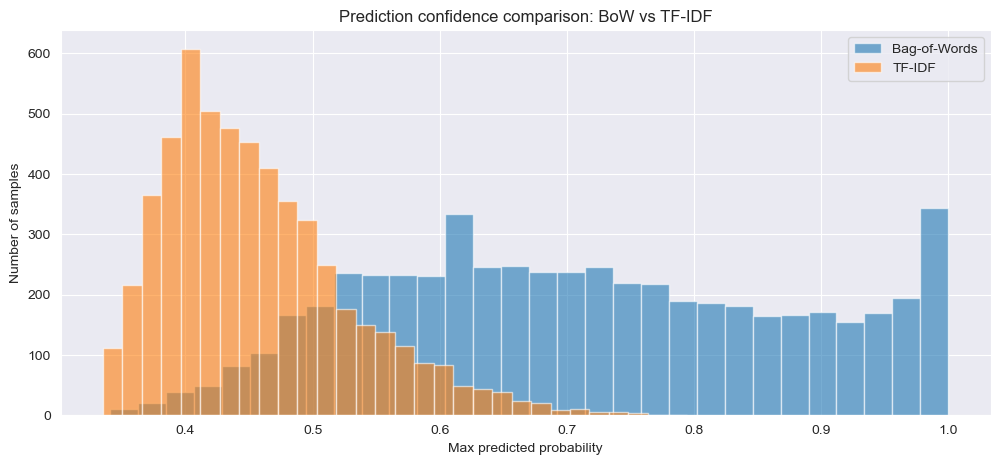

In [18]:
prob_bow = models["LogReg"].predict_proba(X_test_bow)
prob_tfidf = logreg_tfidf.predict_proba(X_test_tfidf)

plt.figure(figsize=(12,5))
plt.hist(prob_bow.max(axis=1), bins=30, alpha=0.6, label="Bag-of-Words")
plt.hist(prob_tfidf.max(axis=1), bins=30, alpha=0.6, label="TF-IDF")
plt.xlabel("Max predicted probability")
plt.ylabel("Number of samples")
plt.title("Prediction confidence comparison: BoW vs TF-IDF")
plt.legend()
plt.show()

In [21]:
classes_tfidf = logreg_tfidf.classes_
classes_bow = models["LogReg"].classes_

def predict_with_threshold(proba, classes, threshold, neutral_label="neutral"):
    max_idx = proba.argmax(axis=1)
    max_val = proba.max(axis=1)
    preds = classes[max_idx].astype(object)
    mask = max_val < threshold
    preds[mask] = neutral_label
    return preds

grid = np.linspace(0.35, 0.80, 20)

best_t_tfidf, best_f1_tfidf, best_pred_tfidf = None, -1.0, None
for t in grid:
    preds = predict_with_threshold(prob_tfidf, classes_tfidf, t)
    f1 = f1_score(y_test, preds, average="macro")
    if f1 > best_f1_tfidf:
        best_f1_tfidf, best_t_tfidf, best_pred_tfidf = f1, t, preds

print(f"TF-IDF best threshold: {best_t_tfidf:.3f}")
print(f"TF-IDF accuracy: {accuracy_score(y_test, best_pred_tfidf):.4f}, macro-F1: {best_f1_tfidf:.4f}")
print("TF-IDF classification report at best threshold")
print(classification_report(y_test, best_pred_tfidf, digits=3))
print("TF-IDF confusion matrix at best threshold:\n", confusion_matrix(y_test, best_pred_tfidf))

preds_bow_argmax = classes_bow[prob_bow.argmax(axis=1)]
f1_bow_argmax = f1_score(y_test, preds_bow_argmax, average="macro")

best_t_bow, best_f1_bow, best_pred_bow = 0.0, f1_bow_argmax, preds_bow_argmax
for t in grid:
    preds = predict_with_threshold(prob_bow, classes_bow, t)
    f1 = f1_score(y_test, preds, average="macro")
    if f1 > best_f1_bow + 1e-4:
        best_f1_bow, best_t_bow, best_pred_bow = f1, t, preds

print(f"\nBoW default (argmax) macro-F1: {f1_bow_argmax:.4f}")
print(f"BoW best threshold: {best_t_bow:.3f}")
print(f"BoW accuracy: {accuracy_score(y_test, best_pred_bow):.4f}, macro-F1: {best_f1_bow:.4f}")
print("BoW classification report at chosen threshold")
print(classification_report(y_test, best_pred_bow, digits=3))
print("BoW confusion matrix at chosen threshold:\n", confusion_matrix(y_test, best_pred_bow))

TF-IDF best threshold: 0.350
TF-IDF accuracy: 0.3686, macro-F1: 0.3175
TF-IDF classification report at best threshold
              precision    recall  f1-score   support

    negative      0.272     0.141     0.186      1556
     neutral      0.411     0.632     0.498      2224
    positive      0.316     0.234     0.269      1717

    accuracy                          0.369      5497
   macro avg      0.333     0.336     0.317      5497
weighted avg      0.342     0.369     0.338      5497

TF-IDF confusion matrix at best threshold:
 [[ 219  961  376]
 [ 323 1405  496]
 [ 262 1053  402]]

BoW default (argmax) macro-F1: 0.6958
BoW best threshold: 0.468
BoW accuracy: 0.7006, macro-F1: 0.7008
BoW classification report at chosen threshold
              precision    recall  f1-score   support

    negative      0.749     0.609     0.671      1556
     neutral      0.629     0.770     0.692      2224
    positive      0.789     0.694     0.739      1717

    accuracy                      

In [22]:
final_errors_bow = pd.DataFrame({
    "text": df.loc[y_test.index, "text"].values,
    "true": y_test.values,
    "pred": best_pred_bow,
    "prob": prob_bow.max(axis=1)
})
final_errors_tfidf = pd.DataFrame({
    "text": df.loc[y_test.index, "text"].values,
    "true": y_test.values,
    "pred": best_pred_tfidf,
    "prob": prob_tfidf.max(axis=1)
})

final_errors_bow = final_errors_bow[final_errors_bow["true"] != final_errors_bow["pred"]]
final_errors_tfidf = final_errors_tfidf[final_errors_tfidf["true"] != final_errors_tfidf["pred"]]

print(f"Misclassified (BoW): {len(final_errors_bow)} / {len(y_test)}")
print(f"Misclassified (TF-IDF @ {best_t_tfidf:.3f}): {len(final_errors_tfidf)} / {len(y_test)}")

print("\n--- BoW: False Positives for 'positive' ---")
display(final_errors_bow[(final_errors_bow["pred"] == "positive") & (final_errors_bow["true"] != "positive")].head(10)[["text","true","prob"]])

print("\n--- BoW: False Negatives of 'positive' ---")
display(final_errors_bow[(final_errors_bow["true"] == "positive") & (final_errors_bow["pred"] != "positive")].head(10)[["text","pred","prob"]])

print("\n--- TF-IDF: False Positives for 'positive' ---")
display(final_errors_tfidf[(final_errors_tfidf["pred"] == "positive") & (final_errors_tfidf["true"] != "positive")].head(10)[["text","true","prob"]])

print("\n--- TF-IDF: False Negatives of 'positive' ---")
display(final_errors_tfidf[(final_errors_tfidf["true"] == "positive") & (final_errors_tfidf["pred"] != "positive")].head(10)[["text","pred","prob"]])


Misclassified (BoW): 1646 / 5497
Misclassified (TF-IDF @ 0.350): 3471 / 5497

--- BoW: False Positives for 'positive' ---


,text,true,prob
14,is watching the jonas brothers special on sky ...,neutral,0.710099
30,Good Morning...hoping to throw back some coffe...,neutral,0.984152
35,_richie I also saw u on American Idol great pe...,neutral,0.869264
43,I chilled in my room with my baby book missed ...,neutral,0.968366
71,i thought you would win! Fabulously40 have s...,negative,0.573627
78,_mueller yes i love it its just a little bit ...,neutral,0.567306
98,it`s Under a Honeymoon by The Good Life,neutral,0.659418
100,aahhh! nyc placements have started to come out...,neutral,0.952337
102,"Yeah, I`m not really feeling it either. Of co...",negative,0.503443
105,Happy Birthday to meeeee!! Excited to go out t...,neutral,0.870198



--- BoW: False Negatives of 'positive' ---


,text,pred,prob
29,the sunset view is SO beautiful from my room!,neutral,0.616516
38,cant **** wait mate!!! it is goin to fantasti...,neutral,0.504342
47,i want so bad to go to the mcfly`s concert,neutral,0.732018
60,"it`s the small things in life that count, lik...",neutral,0.556918
62,After 42 hours of not sleeping it is time for ...,neutral,0.614036
77,The NVIDIA ION-based Lenovo IdeaPad S12 ( htt...,neutral,0.635013
79,sounds like my kinda day,neutral,0.628361
87,Just spent the evening at a gala for her high ...,neutral,0.453122
106,liking my fake tan orange colour,neutral,0.615361
125,are u planning on doing cardio for 1.5 hrs? I...,negative,0.487968



--- TF-IDF: False Positives for 'positive' ---


,text,true,prob
0,"awww bb, you sound lonely I want to drive up...",negative,0.487806
7,Aww Yeah I feel you. I know its hard.,negative,0.427989
9,Freakin` frustrated why can`t my coach realize...,negative,0.609727
26,Phone will die soon. What to do now? Oh no!,negative,0.374846
27,and were going to pune tomorrow,neutral,0.554475
32,Locked out of my **** house!,neutral,0.393907
36,"me too she better be back soon! dude, this i...",negative,0.470103
43,I chilled in my room with my baby book missed ...,neutral,0.424419
45,**** elora danan are breaking up too and im m...,negative,0.583635
70,Sittin at the hospital with isaac cause he hit...,negative,0.420995



--- TF-IDF: False Negatives of 'positive' ---


,text,pred,prob
1,don`t be worried! I`m safe and sound! <3 you!,neutral,0.473193
18,Happy Mother`s Day Mama bear,neutral,0.402401
22,just got the bouquet of flowers for my mom HE...,neutral,0.455894
23,omg J.O.N.A.S. is my new fave show <3 one gues...,neutral,0.396486
29,the sunset view is SO beautiful from my room!,neutral,0.464348
31,ohhh yea it is from the same film and this o...,neutral,0.404831
33,"MIT bookstore has best book selection, but it`...",neutral,0.633728
34,"haha, its cos one of your `tweets` was smile ...",neutral,0.487133
38,cant **** wait mate!!! it is goin to fantasti...,neutral,0.452003
48,":3, Youtube loves my HD videos well maybe.",neutral,0.404612


### Summary

#### Error Patterns
Analysis of TF-IDF classifier mistakes shows two dominant patterns:

1. **False Positives (predicted positive, actually negative or neutral)**
   Many texts contain *empathetic* or *supportive* expressions (e.g., “awww bb, you sound lonely”, “Aww yeah I feel you”),
   which include emotionally charged but contextually *non-positive* words.
   The classifier interprets emotional tone as positive even when the actual sentiment is sadness or frustration.

2. **False Negatives (missed positive samples)**
   Posts with clear positive meaning (e.g., “Happy Mother’s Day Mama bear”, “the sunset view is SO beautiful”)
   are often misclassified as neutral.
   This happens because the TF-IDF model down-weighted frequent, high-signal sentiment words (*happy, love, beautiful*),
   and gave excessive weight to rare, topic-specific tokens.

---

#### Confidence Distribution
The histogram of prediction probabilities confirms the difference in model confidence:
- **Bag-of-Words** produces a broad, right-shifted curve — the model is confident and discriminative.
- **TF-IDF** probabilities cluster around 0.4–0.5 — the model is uncertain and struggles to separate classes.
After threshold tuning, the TF-IDF accuracy slightly improved, but overall reliability remained low.

---

#### Suggested Improvements
1. **Use n-grams (bigrams/trigrams)**
   Capture short contextual phrases (e.g., “so happy”, “feel bad”) that express sentiment more accurately than single words.

2. **Integrate sentiment lexicons or pretrained embeddings**
   Combine TF-IDF or BoW features with sentiment dictionaries or embeddings (Word2Vec, GloVe) to preserve emotional meaning.

3. **Refine preprocessing and weighting**
   Avoid over-aggressive IDF penalization, apply class balancing, and include lemmatization to reduce sparsity.

---

**Conclusion:**
The TF-IDF classifier often confuses empathy and emotion intensity with positivity and loses essential frequent sentiment cues.
Its lower confidence and higher misclassification rate confirm that, for th


І на фінал кернел для натхнення і ознайомлення з рішенням оригінальної задачі. Багато цікавих візуалізацій і аналізу є тут, а також тут розвʼязується саме проблема named entitty recognition і можна ознайомитись як це робиться - вона дещо складніша по своїй суті ніж класифікація, подумайте, чому:

https://www.kaggle.com/code/tanulsingh077/twitter-sentiment-extaction-analysis-eda-and-model